In [1]:
import phylodata
from src.datasets.load_phylodata import load_phylodata_experiments

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from tqdm import tqdm
from src.datasets.load_trees import load_trees_from_file

from src.distribution_analysis.process_tree import get_clade_split_df, get_observed_nodes
from src.utils.tree_utils import get_taxa_names

In [2]:
sns.set_style("darkgrid")
sns.set_theme("notebook")

sns.set_palette("colorblind")

FIG_WIDTH = 5
TITLE_FONT_SIZE = 13
LABEL_FONT_SIZE = 12

In [3]:
PLOT_DIRECTORY = Path("plots/model_correlations_plots")
PLOT_DIRECTORY.mkdir(parents=True, exist_ok=True)

### Choose Models

In [4]:
MODELS = [
    "Height (LogNormal) Shorter Branch (Scaled Beta) per partition",
    "Height (LogNormal) Ratio (Beta) per partition",
    "Last Divergence (LogNormal) Branch (LogNormal)per partition",
    "Shorter Branch (LogNormal) per partition",
]
SHORT_MODEL_IDS = {
    "Height (LogNormal) Ratio (Beta) per partition": "HR",
    "Height (LogNormal) Shorter Branch (Scaled Beta) per partition": "SBR",
    "Last Divergence (LogNormal) Branch (LogNormal)per partition": "LD",
    "Shorter Branch (LogNormal) per partition": "SB",
    "True": ""
}
num_models = len(MODELS)

### Load phylodata experiments

In [5]:
phylodata.prefer_preview()
experiments = load_phylodata_experiments()

  0%|          | 0/21 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 667.19it/s]


### Load samples

In [6]:
model_trees = {}

for model in tqdm(MODELS):
    experiment_trees = {}
    for experiment in experiments:
        try:
            tree_file = Path(f"data/processed/phylodata-phylodata-{experiment.experiment.human_readable_id.replace("-", "_")}_{model}_samples.trees")
            trees = load_trees_from_file(tree_file)
            experiment_trees[experiment.experiment.human_readable_id] = trees
        except:
            print(f"Error processing {experiment.experiment.human_readable_id}")

    model_trees[model] = experiment_trees

ref_experiment_trees = {}
for experiment in experiments:
    try:
        ref_tree_file = experiment.get_file_of_type(phylodata.FileType.POSTERIOR_TREES)
        ref_trees = load_trees_from_file(ref_tree_file.local_path)
        ref_experiment_trees[experiment.experiment.human_readable_id] = ref_trees
    except:
        pass

model_trees["True"] = ref_experiment_trees

  0%|          | 0/4 [00:00<?, ?it/s]

Error processing tornabene-2016-repeated-k72b
Error processing winger-2015-inferring-g4kz


 25%|██▌       | 1/4 [01:20<04:02, 80.87s/it]

Error processing tornabene-2016-repeated-k72b
Error processing winger-2015-inferring-g4kz


 50%|█████     | 2/4 [03:13<03:19, 99.65s/it]

Error processing tornabene-2016-repeated-k72b
Error processing winger-2015-inferring-g4kz


 75%|███████▌  | 3/4 [04:49<01:38, 98.13s/it]

Error processing tornabene-2016-repeated-k72b
Error processing winger-2015-inferring-g4kz


100%|██████████| 4/4 [06:40<00:00, 100.06s/it]


In [7]:
short_experiment_ids = {
    experiment_id: f"PD{i + 1}" for i, experiment_id in enumerate(sorted(experiment_trees.keys()))
}
num_experiments = len(short_experiment_ids)

### Collect clades and clade splits for each experiment

In [ ]:
from typing import Any

clade_dfs = []

for model in (MODELS + ["True"]):
    experiment_trees = model_trees[model]
    for experiment in tqdm(experiment_trees.keys()):
        exp_trees = experiment_trees[experiment]
        taxa_names = get_taxa_names(exp_trees[0])
        observed_nodes, observed_splits = get_observed_nodes(exp_trees, taxa_names)
        clade_df = get_clade_split_df(observed_splits)
        
        clade_df["model"] = model
        clade_df["experiment_id"] = experiment
        
        clade_dfs.append(clade_df)

clade_df = pd.concat(clade_dfs)

  5%|▌         | 1/19 [00:00<00:02,  6.01it/s]

In [ ]:
clade_df["height"] = clade_df["tree_height"] - clade_df["height"]
clade_df["left_height"] = clade_df["height"] - clade_df["left_branch"]
clade_df["right_height"] = clade_df["height"] - clade_df["right_branch"]
clade_df["parent_height"] = clade_df["height"] + clade_df["branch_to_parent"]

### Investigate global correlations between different variables

In [ ]:
MIN_NUM_OBSEVRATIONS = 5

In [ ]:
CORRELATION_ANALYSES = {
    "Sibling Branches": ["left_branch", "right_branch"],
    "Child Parent Branch": ["branch_to_parent", "left_branch"],
    "Branch and Tree Height": ["branch_to_parent", "tree_height"],
    "Branch and Height": ["branch_to_parent", "height"],
    "Sibling Heights": ["left_height", "right_height"],
    "Child Parent Heights": ["parent_height", "height"],
    "Height and Tree Height": ["height", "tree_height"],
}

In [ ]:
%%skip

for analysis_name, columns in CORRELATION_ANALYSES.items():
    clade_corrs = []
    for (exp_id, model), group in clade_df.groupby(["experiment_id", "model"]):
        for clade, clade_group in group.groupby("clade_split"):
            if clade_group[columns].shape[0] > MIN_NUM_OBSEVRATIONS:
                corr = clade_group[columns].corr().iloc[0, 1]
            else:
                corr = np.nan
            clade_corrs.append({
                "experiment_id": exp_id,
                "model": model,
                "clade": clade,
                "corr": corr
            })
    clade_corrs_df = pd.DataFrame(clade_corrs)

    num_plots = (num_models + 1) * num_experiments

    ncols = 4
    nrows = int(np.ceil(num_plots / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(2*FIG_WIDTH, nrows * 0.4),
        sharex=True
    )

    axes_flat = axes.flatten(order="F") if isinstance(axes, np.ndarray) else [axes]

    ax_id = 0
    for exp_id in short_experiment_ids:
        for model in ["True"] + MODELS:
            data = clade_corrs_df[
                (clade_corrs_df["model"] == model) & (clade_corrs_df["experiment_id"] == exp_id)
            ]["corr"].dropna()

            label = short_experiment_ids[exp_id] + " " + SHORT_MODEL_IDS[model]

            if model == "True":
                color_idx = 1
            else:
                color_idx = 0
            
            ax = axes_flat[ax_id]
            ax.hist(data, bins=np.linspace(-1, 1, 12),color=sns.color_palette()[color_idx])
            ax.axvline(0, color='gray', linestyle='--', linewidth=1)  # Add a line for x=0
            ax.set_ylabel(label, rotation=0, ha='left', va='center', labelpad=60)
            ax.set_yticks([])
            ax.set_xlim(-1, 1)
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)

            ax_id += 1

    fig.supxlabel("Per-Split Correlation Distribution of " + analysis_name, fontsize=LABEL_FONT_SIZE)
    plt.tight_layout()

    plt.subplots_adjust(hspace=0.1, bottom=0.075, left=0.0)

    plt.savefig(PLOT_DIRECTORY / f"{analysis_name}.svg", bbox_inches = "tight")
    plt.show()
    

UsageError: Cell magic `%%skip` not found.


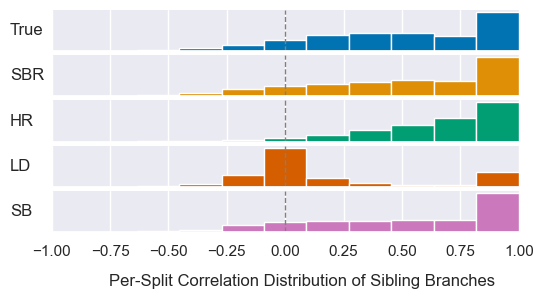

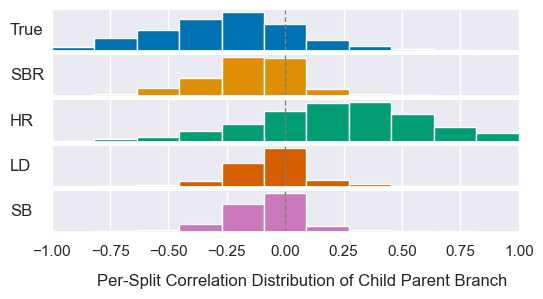

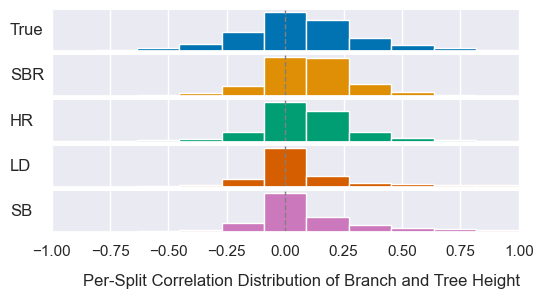

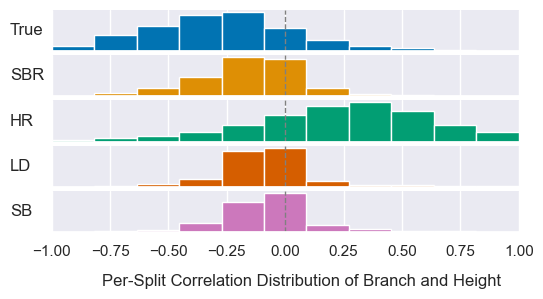

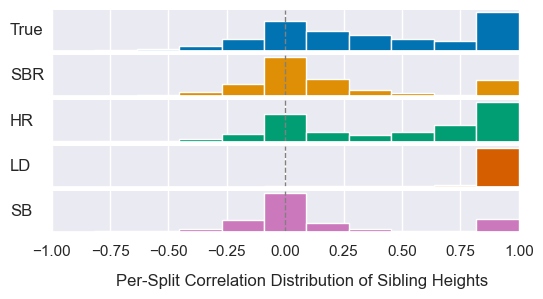

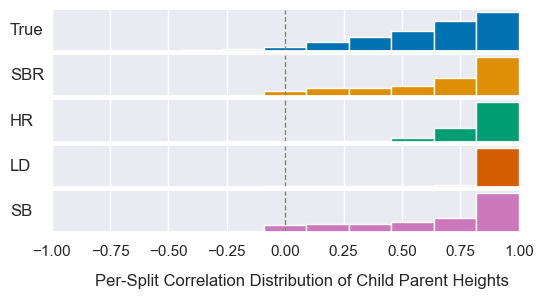

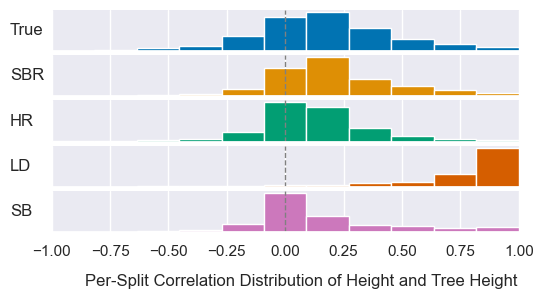

In [ ]:
for analysis_name, columns in CORRELATION_ANALYSES.items():
    clade_corrs = []
    for (exp_id, model), group in clade_df.groupby(["experiment_id", "model"]):
        for clade, clade_group in group.groupby("clade_split"):
            if clade_group[columns].shape[0] > MIN_NUM_OBSEVRATIONS:
                corr = clade_group[columns].corr().iloc[0, 1]
            else:
                corr = np.nan
            clade_corrs.append({
                "experiment_id": exp_id,
                "model": model,
                "clade": clade,
                "corr": corr
            })
    clade_corrs_df = pd.DataFrame(clade_corrs)

    num_plots = (num_models + 1)

    ncols = 1
    nrows = int(np.ceil(num_plots / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(FIG_WIDTH, nrows * 0.6),
        sharex=True
    )

    axes_flat = axes.flatten(order="F") if isinstance(axes, np.ndarray) else [axes]

    ax_id = 0
    for i, model in enumerate(["True"] + MODELS):
        data = clade_corrs_df[clade_corrs_df["model"] == model]["corr"].dropna()

        label = SHORT_MODEL_IDS[model] or "True"

        ax = axes_flat[ax_id]
        ax.hist(data, bins=np.linspace(-1, 1, 12),color=sns.color_palette()[i])
        ax.axvline(0, color='gray', linestyle='--', linewidth=1)  # Add a line for x=0
        ax.set_ylabel(label, rotation=0, ha='left', va='center', labelpad=30)
        ax.set_yticks([])
        ax.set_xlim(-1, 1)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

        ax_id += 1

    fig.supxlabel("Per-Split Correlation Distribution of " + analysis_name, fontsize=LABEL_FONT_SIZE)
    plt.tight_layout()

    plt.subplots_adjust(hspace=0.1, bottom=0.2, left=0.0)

    plt.savefig(PLOT_DIRECTORY / f"{analysis_name}.svg", bbox_inches = "tight")
    plt.show()

### Investigate correlations along the tree between different variables

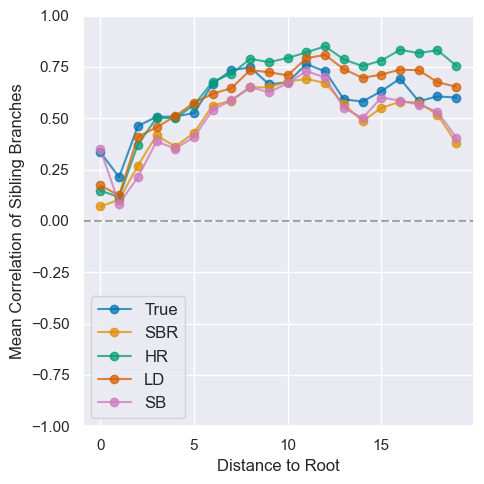

KeyboardInterrupt: 

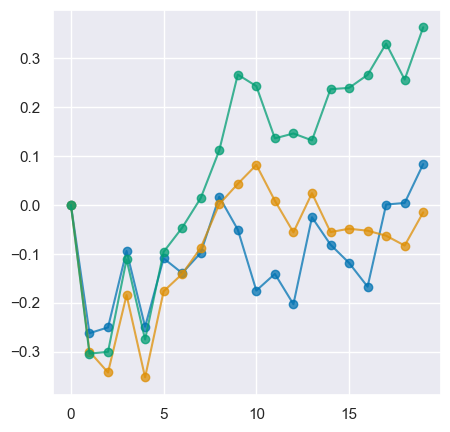

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

MAX_DISTANCE = 20
distance_values = list(range(MAX_DISTANCE))

for analysis_name, (col_1, col_2) in CORRELATION_ANALYSES.items():
    plt.figure(figsize=(FIG_WIDTH, FIG_WIDTH))
    
    for model in ["True"] + MODELS:
        sum_corrs = [0.0 for _ in range(MAX_DISTANCE)]
        num_corrs = [0 for _ in range(MAX_DISTANCE)]

        for exp_id, short_exp_id in short_experiment_ids.items():
            exp_group = clade_df[
                (clade_df.experiment_id == exp_id) & (clade_df.model == model)
            ]
            
            for dist in distance_values:
                subset = exp_group[exp_group["distance_to_root"] == dist]
            
                # Only calculate if there are enough values
                if subset[col_1].nunique() > 1 and subset[col_2].nunique() > MIN_NUM_OBSEVRATIONS:
                    r, _ = pearsonr(subset[col_1], subset[col_2])
                    sum_corrs[dist] += r
                    num_corrs[dist] += 1
                else:
                    # Not enough data to calculate a correlation
                    pass

        # calculate mean correlation
        mean_corrs = [c / max(1, n) for (c, n) in zip(sum_corrs, num_corrs)]
        
        # plot
        plt.plot(distance_values, mean_corrs, marker='o', label=SHORT_MODEL_IDS[model] or "True", alpha=0.75)

    plt.ylim(-1, 1)
    plt.axhline(0, color='grey', linestyle='--', alpha=0.7)

    plt.xlabel("Distance to Root", fontsize=LABEL_FONT_SIZE)
    plt.ylabel("Mean Correlation of " + analysis_name, fontsize=LABEL_FONT_SIZE)
    plt.legend(fontsize=LABEL_FONT_SIZE)
    
    plt.tight_layout()

    plt.savefig(PLOT_DIRECTORY / f"{analysis_name} along Tree.svg", bbox_inches = "tight")
    plt.show()